# MMFDB · Fluorescence Correlation Spectroscopy (FCS)

**FCS** reads diffusion and concentration from the *timing* of photons. We
simulate one freely diffusing species with tttrlib, store the photon stream in
**MMFDB**, fetch it back, and correlate it to recover the diffusion time
$\tau_D = w_0^2 / 4D$.

In [1]:
%matplotlib inline
import logging, warnings
for _n in ("numexpr", "mmfdb"):
    logging.getLogger(_n).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="nopython is set for njit")

import numpy as np
import matplotlib.pyplot as plt
import tttrlib
from pathlib import Path
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow

## Simulate a diffusing species and store it in MMFDB

The ground truth: a large, slowly diffusing molecule `D = 0.045 um^2/ms` in a
`w0 = 0.3 um` focus, so `tau_D = w0^2/4D` should come out around 500 us.

In [2]:
D, W0 = 0.045, 0.3                     # ground truth (slow, large molecule)
config = {
    "settings": {"dt": 0.01, "n_ph_max": 800_000, "n_channels": 2,
                 "fast_grid_bbox": True, "active_margin": 1.0},
    "box": {"xy": 2.0, "z": 4.0},
    "species": [{"D": D, "q": [50.0, 50.0]}],
    "k_rad": [0.0], "k_nrad": [0.0],
    "background": [0.05, 0.05], "population": [1.5],
    "excitation": {"type": "gaussian3d", "w0": W0, "z0": 2.0,
                   "extent_xy": 2.0, "extent_z": 4.0, "spacing": 0.1},
}
engine = tttrlib.SimEngine.from_dict(config); engine.run()
tttr = engine.to_tttr(dt=0.01, n_channels=2, laser_period=32.0)
print("simulated", len(tttr), "photons")

simulated 800000 photons


Store the simulated file, then fetch it back by handle — round-tripping
through MMFDB exactly like a real measurement.

In [3]:
import tempfile
tmp = Path(tempfile.mkdtemp()) / "fcs_sim.spc"
tttr.write(str(tmp))

wf = BurstWorkflow.demo()
handle = wf.register(tmp)
local = wf.fetch(handle)                # pulled back from MMFDB
data = tttrlib.TTTR(str(local), "SPC-130")
print("correlating", len(data), "photons from MMFDB handle", handle[:8])

correlating 800000 photons from MMFDB handle 54a0f0a8


## Correlate

The autocorrelation `G(tau)` starts high (amplitude ~ 1/N) and decays as
molecules leave the focus; its midpoint marks the diffusion time.

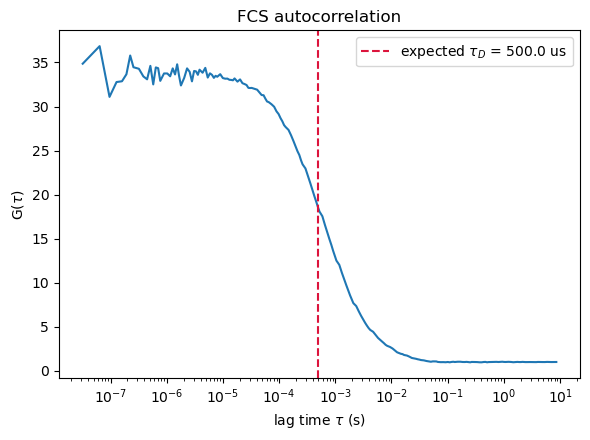

amplitude G(0)-1 = 33.86  ->  ~0.03 molecules in focus


In [4]:
cor = tttrlib.Correlator(tttr=data, n_casc=25, n_bins=8, make_fine=False)
lag = np.asarray(cor.x_axis)          # seconds
g = np.asarray(cor.correlation)
keep = lag > 0

tau_D = W0**2 / (4 * D) * 1e-3         # ground-truth diffusion time (s)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.semilogx(lag[keep], g[keep], color="#1f77b4")
ax.axvline(tau_D, color="crimson", ls="--", label=f"expected $\\tau_D$ = {tau_D*1e6:.1f} us")
ax.set_xlabel("lag time $\\tau$ (s)"); ax.set_ylabel("G($\\tau$)")
ax.set_title("FCS autocorrelation"); ax.legend()
fig.tight_layout(); plt.show()
print(f"amplitude G(0)-1 = {g[keep][0]-1:.2f}  ->  ~{1/(g[keep][0]-1):.2f} molecules in focus")

In [5]:
wf.close()
print("Finished.")

Finished.
